<a href="https://colab.research.google.com/github/UDAY2232/Intent-AI/blob/main/Intent_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle tensorflow opencv-python matplotlib seaborn

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
!unzip "/content/archive (18).zip" -d /content/data

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/train/sad/Training_65242339.jpg  
  inflating: /content/data/train/sad/Training_65267116.jpg  
  inflating: /content/data/train/sad/Training_65275626.jpg  
  inflating: /content/data/train/sad/Training_6529266.jpg  
  inflating: /content/data/train/sad/Training_65329617.jpg  
  inflating: /content/data/train/sad/Training_65338712.jpg  
  inflating: /content/data/train/sad/Training_65338797.jpg  
  inflating: /content/data/train/sad/Training_65387162.jpg  
  inflating: /content/data/train/sad/Training_65404494.jpg  
  inflating: /content/data/train/sad/Training_65426218.jpg  
  inflating: /content/data/train/sad/Training_65430136.jpg  
  inflating: /content/data/train/sad/Training_65437377.jpg  
  inflating: /content/data/train/sad/Training_6545735.jpg  
  inflating: /content/data/train/sad/Training_65463385.jpg  
  inflating: /content/data/train/sad/Training_65473985.jpg  
  inflating: /content/data/train/sad

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/data/train"
test_dir = "/content/data/test"

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),   # ResNet size
    color_mode='rgb',
    batch_size=64,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    color_mode='rgb',
    batch_size=64,
    class_mode='categorical'
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras import layers, models

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(7, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [ ]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 424s 902ms/step - accuracy: 0.2508 - loss: 1.8222 - val_accuracy: 0.2920 - val_loss: 1.7822
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 399s 887ms/step - accuracy: 0.2862 - loss: 1.7538 - val_accuracy: 0.3454 - val_loss: 1.6752
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 398s 885ms/step - accuracy: 0.2994 - loss: 1.7288 - val_accuracy: 0.3525 - val_loss: 1.6471
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 393s 875ms/step - accuracy: 0.3101 - loss: 1.7122 - val_accuracy: 0.3703 - val_loss: 1.6247
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 389s 866ms/step - accuracy: 0.3144 - loss: 1.7017 - val_accuracy: 0.3725 - val_loss: 1.6119
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 385s 857ms/step - accuracy: 0.3216 - loss: 1.6943 - val_accuracy: 0.3777 - val_loss: 1.5957
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 384s 856ms/step - accuracy: 0.3267 - loss: 1.6872 - val_accuracy: 0.3823 - val_loss: 1.5919
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 387s 863ms/step - accuracy: 0.3304 -

In [ ]:
# Unfreeze last layers
for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_fine = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 452s 940ms/step - accuracy: 0.2489 - loss: 2.1825 - val_accuracy: 0.3199 - val_loss: 1.7926
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 404s 900ms/step - accuracy: 0.2783 - loss: 1.9198 - val_accuracy: 0.3346 - val_loss: 1.7110
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 402s 893ms/step - accuracy: 0.2903 - loss: 1.8165 - val_accuracy: 0.3264 - val_loss: 1.7075
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 395s 880ms/step - accuracy: 0.3063 - loss: 1.7626 - val_accuracy: 0.3055 - val_loss: 1.7176
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 404s 898ms/step - accuracy: 0.3169 - loss: 1.7262 - val_accuracy: 0.3763 - val_loss: 1.6131
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 403s 898ms/step - accuracy: 0.3250 - loss: 1.7008 - val_accuracy: 0.3147 - val_loss: 1.6868
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 403s 898ms/step - accuracy: 0.3269 - loss: 1.6911 - val_accuracy: 0.3612 - val_loss: 1.6973
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 399s 888ms/step - accuracy: 0.3421 -

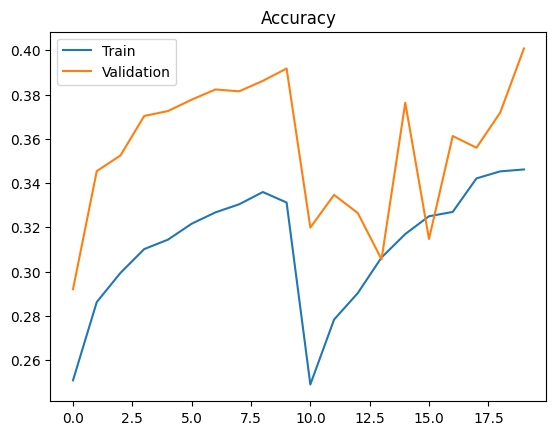

In [ ]:
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'])
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'])

plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

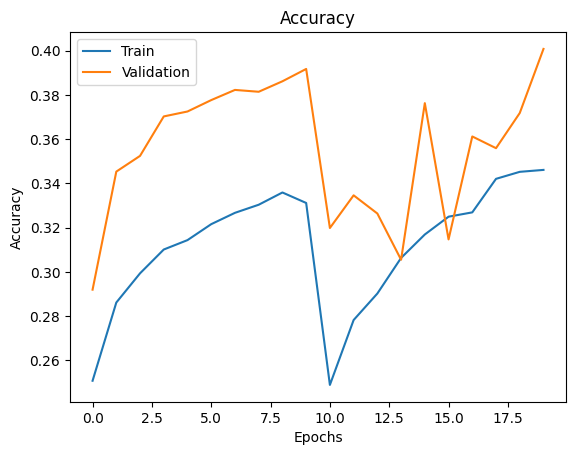

In [ ]:
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'])
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'])

plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
loss, acc = model.evaluate(test_data)
print("Final Accuracy:", acc)

113/113 ━━━━━━━━━━━━━━━━━━━━ 21s 182ms/step - accuracy: 0.4008 - loss: 1.5785
Final Accuracy: 0.40080803632736206


In [ ]:
model.save("face_resnet_model.h5")

In [ ]:
!pip install librosa soundfile numpy tensorflow

In [ ]:
!unzip "/content/archive (19).zip" -d /content/datav

Archive:  /content/archive (19).zip
  inflating: /content/datav/Actor_01/03-01-01-01-01-01-01.wav  
  inflating: /content/datav/Actor_01/03-01-01-01-01-02-01.wav  
  inflating: /content/datav/Actor_01/03-01-01-01-02-01-01.wav  
  inflating: /content/datav/Actor_01/03-01-01-01-02-02-01.wav  
  inflating: /content/datav/Actor_01/03-01-02-01-01-01-01.wav  
  inflating: /content/datav/Actor_01/03-01-02-01-01-02-01.wav  
  inflating: /content/datav/Actor_01/03-01-02-01-02-01-01.wav  
  inflating: /content/datav/Actor_01/03-01-02-01-02-02-01.wav  
  inflating: /content/datav/Actor_01/03-01-02-02-01-01-01.wav  
  inflating: /content/datav/Actor_01/03-01-02-02-01-02-01.wav  
  inflating: /content/datav/Actor_01/03-01-02-02-02-01-01.wav  
  inflating: /content/datav/Actor_01/03-01-02-02-02-02-01.wav  
  inflating: /content/datav/Actor_01/03-01-03-01-01-01-01.wav  
  inflating: /content/datav/Actor_01/03-01-03-01-01-02-01.wav  
  inflating: /content/datav/Actor_01/03-01-03-01-02-01-01.wav  
  in

In [ ]:
DATA_PATH = "/content/archive (19).zip"

In [ ]:
import librosa
import numpy as np
import os

In [ ]:
def extract_features(file_path):
    audio, sr = librosa.load(file_path, duration=3)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc = np.mean(mfcc.T, axis=0)

    return mfcc

In [ ]:
DATA_PATH = "/content/datav"
X, y = [], []

for root, _, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith(".wav"):
            path = os.path.join(root, file)

            features = extract_features(path)
            X.append(features)

            # The label is the third element after splitting by '-', e.g., '03-01-01-01-01-01-01.wav' -> '01'
            label = file.split("-")[2]
            y.append(int(label))

X = np.array(X)
y = np.array(y)

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
from tensorflow.keras import layers, models

voice_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(40,)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dense(y_train.shape[1], activation='softmax')
])

voice_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = voice_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32
)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.2665 - loss: 1.9309 - val_accuracy: 0.1632 - val_loss: 3.3864
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3646 - loss: 1.6696 - val_accuracy: 0.2812 - val_loss: 2.0010
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4297 - loss: 1.5520 - val_accuracy: 0.4062 - val_loss: 1.5756
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4592 - loss: 1.4471 - val_accuracy: 0.3299 - val_loss: 2.0231
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4796 - loss: 1.3771 - val_accuracy: 0.3073 - val_loss: 2.1937
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5026 - loss: 1.3158 - val_accuracy: 0.2396 - val_loss: 3.1406
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5356 - loss: 1.2580 - val_accuracy: 0.2691 - val_loss: 2.8111
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5477 - loss: 1.1935 - val_accuracy: 0.3021 - val_loss

In [ ]:
voice_model.save("voice_model.h5")

In [ ]:
# Example dummy fusion data (replace with real)
face_features = np.random.rand(len(X), 512)
voice_features = X

fusion_X = np.concatenate([face_features, voice_features], axis=1)
fusion_y = y

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(fusion_X, fusion_y, test_size=0.2)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

fusion_model = Sequential([
    Dense(512, activation='relu', input_shape=(552,)),  # 512 + 40
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    Dense(256, activation='relu'),
    layers.Dropout(0.3),

    Dense(128, activation='relu'),
    Dense(y_train.shape[1], activation='softmax')
])

fusion_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
fusion_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=32
)

Epoch 1/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.2465 - loss: 1.9734 - val_accuracy: 0.1372 - val_loss: 4.1902
Epoch 2/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3420 - loss: 1.7406 - val_accuracy: 0.3576 - val_loss: 1.7815
Epoch 3/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3898 - loss: 1.5826 - val_accuracy: 0.3385 - val_loss: 1.7350
Epoch 4/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4340 - loss: 1.4738 - val_accuracy: 0.3038 - val_loss: 1.9436
Epoch 5/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4701 - loss: 1.4171 - val_accuracy: 0.3368 - val_loss: 2.1041
Epoch 6/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5022 - loss: 1.3262 - val_accuracy: 0.2378 - val_loss: 2.4422
Epoch 7/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5265 - loss: 1.2516 - val_accuracy: 0.2396 - val_loss: 2.5235
Epoch 8/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5638 - loss: 1.1904 - val_accuracy: 0.1997 - val_loss

In [ ]:
fusion_model.save("fusion_model.h5")